# Imports and dataset loading section

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string
import spacy
import nltk
import random
from nltk.corpus import stopwords
import re
!python -m spacy download en_core_web_trf
import en_core_web_sm
!pip install -U spacy-transformers
from scipy import spatial
!pip install gensim
import gensim
import gensim.downloader
from gensim.utils import simple_preprocess
import gensim.corpora as corpora
from gensim.models import CoherenceModel, LdaModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pprint import pprint

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 1.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Seeds fixing in order to obtain in the whole program reproductible results
random.seed(2)
np.random.seed(2)

In [ ]:
# Import the dataset from URL
URL = "https://raw.githubusercontent.com/ProfAI/natural-language-processing/refs/heads/main/datasets/Verifica%20Finale%20-%20Spam%20Detection/spam_dataset.csv"
dataset = pd.read_csv(URL)

# Exploratory Data Analysis

In [ ]:
# Information about the dataset
print(f"Dataset dimensions: {dataset.shape}")
print("The columns names are: ")
for c in dataset.columns:
   print(f"* {c}")

Dataset dimensions: (5171, 4)
The columns names are: 
* Unnamed: 0
* label
* text
* label_num


The dataset presents 5171 observations and 4 columns, including an ID number, a label, a text and a label number.

In [ ]:
# Dataset first 5 rows visualization
dataset.head(5)

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


Focus on the 1st column, which seems to be an ID number.

In [ ]:
# Min and max values to confirm it corresponds to an ID number
max_value = max(dataset['Unnamed: 0'])
min_value = min(dataset['Unnamed: 0'])
print(f"The maximum value is {max_value} and the minimum is {min_value}.")

The maximum value is 5170 and the minimum is 0.


It appears that this column really correspond to Ids numbers for each observation, so it can be deleted as it does not bring any important information to the data.

Focus on the 2nd and 4th columns, which seem to be the label column and its encoding. Looking at the first rows it can be hypothesized that the label "ham" corresponds to label_num = 0, and the label "spam" to label_num = 1. </br>
We count how many times these correspondances are true, in order to check it and eventually individualize errors.

In [ ]:
# Function that counts 1 if hypothetic correspondance is found, else 0
def check_target_encoding(label, label_encoding):
  if (label=='ham' and label_encoding==0) or (label=='spam' and label_encoding==1):
    return 1
  else:
    return 0

# Counting on all dataset
count = 0
for l, le in zip(dataset['label'], dataset['label_num']):
  count+=check_target_encoding(l, le)

print(f"On the total {dataset.shape[0]} observations, the hypothesized correspondance is true {count} times.")

On the total 5171 observations, the hypothesized correspondance is true 5171 times.


As a result, the 'label_num' column really corresponds to the target encoding, and the 'label' column can be removed. </br>
We only keep 'text' and 'label_num' columns.

In [ ]:
# Reduced dataset to 2 columns
dataset = dataset[['text', 'label_num']]

It is necessary to check eventual missing data and duplicates.

In [ ]:
# Count of missing data
dataset.isna().sum()

,0
text,0
label_num,0


There is no missing data.

In [ ]:
# Check the presence of duplicates on the 'text' column
print(f" There are {dataset.duplicated(subset='text').sum()} duplicates in the dataset.")

 There are 178 duplicates in the dataset.


These duplicates need to be removed.

In [ ]:
# Drop of the duplicates
dataset = dataset.drop_duplicates(subset='text')
print(f"The new number of observations in the dataset is {dataset.shape[0]}.")

The new number of observations in the dataset is 4993.


The emails are divided into a binary classification: </br>
* 0 : meaning the email IS NOT a spam
* 1 : meaning the email IS a spam </br>

It is important to count the number of observations for each category.

In [ ]:
label = dataset['label_num']
counts = label.value_counts()
mod_0 = label.unique()[0]
mod_1 =label.unique()[1]
print(f"Label {mod_0} (NON spam emails) = {counts[mod_0]} (corresponding to {counts[mod_0]/counts.sum()*100:.2f}%)")
print(f"Label {mod_1} (SPAM emails) = {counts[mod_1]} (corresponding to {counts[mod_1]/counts.sum()*100:.2f}%)")

Label 0 (NON spam emails) = 3531 (corresponding to 70.72%)
Label 1 (SPAM emails) = 1462 (corresponding to 29.28%)


In this dataset 71% of the observations correspond to regular emails, while 29% are SPAMs: it is a slightly unbalanced dataset.  

Out of curiosity, let's take a look on a random email text.

In [ ]:
import random
random.seed(22)
num = random.randint(0, len(dataset))
dataset['text'][num]

'Subject: mortgage interest rates are at their lowest point ever !\n'

It appears that at the beginning of each text there is "Subject: ". It would be better to remove it.

In [ ]:
dataset['text'] = dataset['text'].apply(lambda x: x[9:])

In [ ]:
dataset

,text,label_num
0,enron methanol ; meter # : 988291\nthis is a f...,0
1,"hpl nom for january 9 , 2001\n( see attached f...",0
2,"neon retreat\nho ho ho , we ' re around to tha...",0
3,"photoshop , windows , office . cheap . main tr...",1
4,re : indian springs\nthis deal is to book the ...,0
...,...,...
5165,"fw : crosstex energy , driscoll ranch # 1 , # ...",0
5166,put the 10 on the ft\nthe transport volumes de...,0
5167,3 / 4 / 2000 and following noms\nhpl can ' t t...,0
5169,industrial worksheets for august 2000 activity...,0


Valutation of the lenght of emails for both categories.

In [ ]:
# Selection of only the text content for spam on one side and non-spam on the other side
text_regular = dataset[dataset['label_num']==0]['text']
text_spam = dataset[dataset['label_num']==1]['text']

In [ ]:
len_all = dataset['text'].str.len().mean()
len_regular = text_regular.str.len().mean()
len_spam = text_spam.str.len().mean()
print(f"Mean length for all emails: {int(len_all)}\nMean length for regular emails: {int(len_regular)}\nMean length for spam emails: {int(len_spam)}")

Mean length for all emails: 1041
Mean length for regular emails: 968
Mean length for spam emails: 1218


There is no relevant difference between length of spam and length of regular emails.

# Dataset Cleaning

Before considering the model choice and training phase, it is essential to clean the dataset. A function is done for this purpose, and perform the following actions: </br>
* lower casing
* removing punctuation
* lemmatization
* removing english stopwords
* removing numbers

In [ ]:
nltk.download('stopwords')

english_stopwords = stopwords.words('english')
nlp = spacy.load('en_core_web_sm')
punctuation = set(string.punctuation)

def data_cleaner(sentence):
    sentence = sentence.lower()
    for c in string.punctuation:
        sentence = sentence.replace(c, " ")
    document = nlp(sentence)
    sentence = ' '.join(token.lemma_ for token in document)
    sentence = ' '.join(word for word in sentence.split() if word not in english_stopwords)
    sentence = re.sub('\d', '', sentence)

    return sentence

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3713492257.py:14: SyntaxWarning: invalid escape sequence '\d'
  sentence = re.sub('\d', '', sentence)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Function application to the dataset
dataset['text'] = dataset['text'].apply(data_cleaner)

Now email texts are clean, it is possible to create some word clouds for spam and for ham emails, in order to see if there are already some recurrent topics.

In [ ]:
# All the emails content of each categories are joined to create an only string
str_regular = "".join(text_regular)
str_spam = "".join(text_spam)

In [ ]:
# Function to create the word clouds together with the top 5 of the most frequent words
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def word_cloud(text, title):
  plt.figure(figsize=(18, 10))

  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.tight_layout(pad=5)
  plt.axis('off')
  plt.title(f"- Word Cloud for {title} emails -", fontsize = 30)
  plt.show()

  # Print the 5 most frequent words
  # First order the words from highest to lowest frequency
  sorted_words = sorted(wordcloud.words_.items(), key=lambda x: x[1], reverse=True)
  # Visualize the top 5
  top5 = [item[0] for item in sorted_words[:5]]
  print(f"The 5 most common words for {title} emails are: {top5}")
  print("\n")

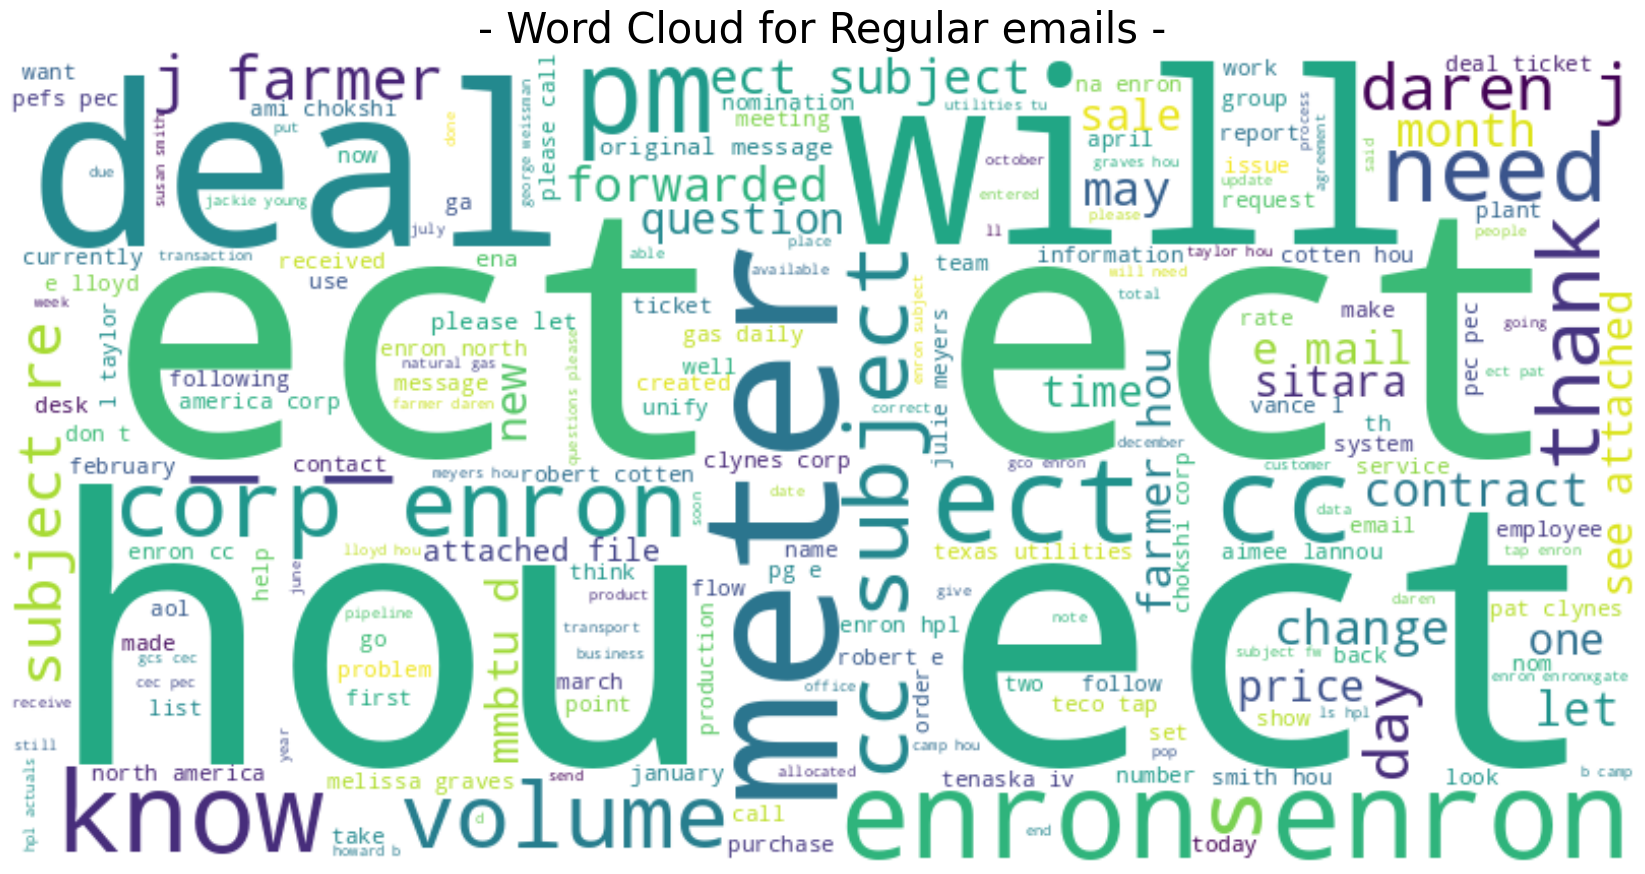

The 5 most common words for Regular emails are: ['hou ect', 'ect ect', 'will', 'deal', 'meter']




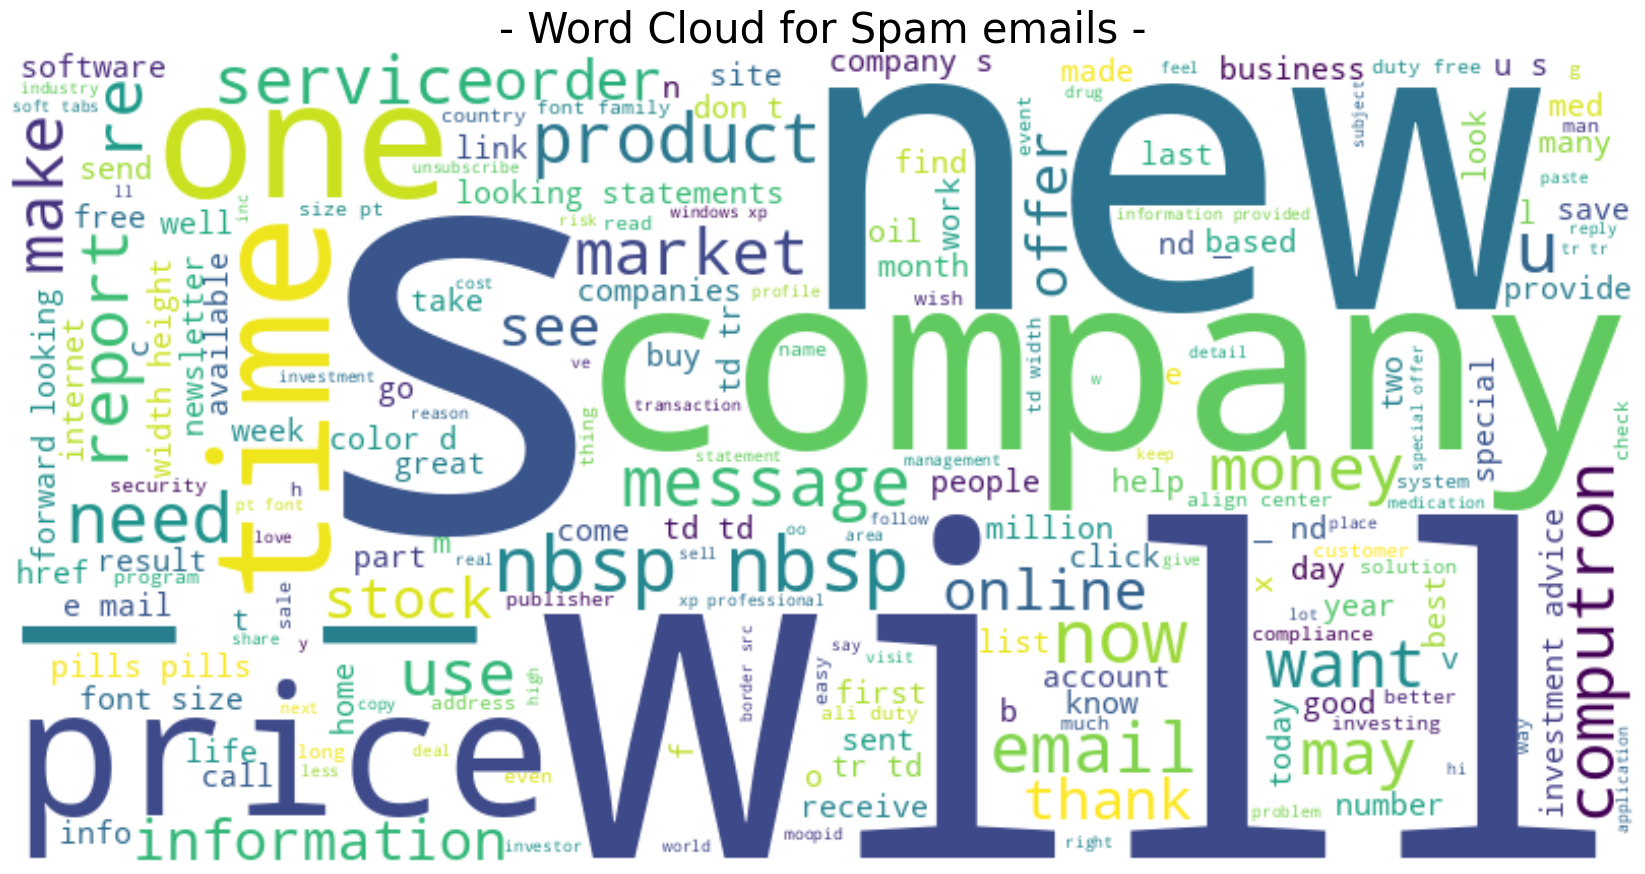

The 5 most common words for Spam emails are: ['s', 'will', 'new', 'company', '_ _']




In [ ]:
# Function application:
word_cloud(str_regular, "Regular")
word_cloud(str_spam, "Spam")

It can be surprising to see that in the ham emails, there are many words that seem to be without high informative content, as "ect ect" or "hou ect". It could be possible to remove this kind of words from email texts, but as they are absent from spam emails, there could be relevant for the classification. </br>
As a result, they are kept.

Now all emails text are clean, it is possible to transform the strings into vectors. </br>
But before, it is important to split train and test sets in order to create the vocabulary only on the train part of the data.

# Train-Test Split

In [ ]:
# Train set chosen with 80% of the examples, test set with 20%
X_train, X_test, y_train, y_test = train_test_split(dataset['text'], dataset['label_num'], test_size=0.2, random_state = 2)

In [ ]:
# Check of the split results
print(f"TRAIN SET: \nNumber of examples: {len(X_train)}")
print(f"Count of label 0 in y_train: {round((y_train == 0).sum()/len(X_train)*100, 2)}%")
print(f"Count of label 1 in y_train: {round((y_train == 1).sum()/len(X_train)*100, 2)}% \n")

print(f"TEST SET: \nNumber of examples: {len(X_test)}")
print(f"Count of label 0 in y_test: {round((y_test == 0).sum()/len(X_test)*100, 2)}%")
print(f"Count of label 1 in y_test: {round((y_test == 1).sum()/len(X_test)*100, 2)}%")

TRAIN SET: 
Number of examples: 3994
Count of label 0 in y_train: 70.96%
Count of label 1 in y_train: 29.04% 

TEST SET: 
Number of examples: 999
Count of label 0 in y_test: 69.77%
Count of label 1 in y_test: 30.23%


The initial dataset proportions are respected: 70% of ham vs 30% of spam.

# Tf-IDF Vectorization Method

The Tf-IDF method is prefered to the classic Bag Of Word to perform the text vectorization, as it seems more relevant to give higher weight to more informative words.

In [ ]:
# Istance of the vectorizer
tfidfvec = TfidfVectorizer()
# Fitting and transformation of the X_train set
X_train_vect = tfidfvec.fit_transform(X_train).toarray()
# Transformation of the X_test test
X_test_vect = tfidfvec.transform(X_test).toarray()

# Classification Model

Logistic regression model is considered.

In [ ]:
# Model istance, with parameter 'balanced' to help with the unbalanced data
log_reg_model = LogisticRegression(class_weight='balanced')

In [ ]:
# Fitting on train set
log_reg_model.fit(X_train_vect, y_train)

LogisticRegression(class_weight='balanced')

In [ ]:
# F1 scores calculations for both train and test sets
log_reg_f1_test = f1_score(y_test, log_reg_model.predict(X_test_vect))
log_reg_f1_train = f1_score(y_train, log_reg_model.predict(X_train_vect))
print(f"F1 score on train set is {round(log_reg_f1_train, 2)}\nF1 score on test set is {round(log_reg_f1_test, 2)}")

F1 score on train set is 0.96
F1 score on test set is 0.93


These F1 values are good, and there is no sign of overfitting. </br>
A visualization of the confusion matrix gives an idea of the model performances in details.

In [ ]:
def confusionmatrix(X, y, model, set, y_pred=None):
  if y_pred is None:
    y_pred = model.predict(X)
  cm = confusion_matrix(y, y_pred)
  matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
  matrix.plot(cmap=plt.cm.Blues)
  plt.title(f"Confusion Matrix for {set} Set")
  plt.show()

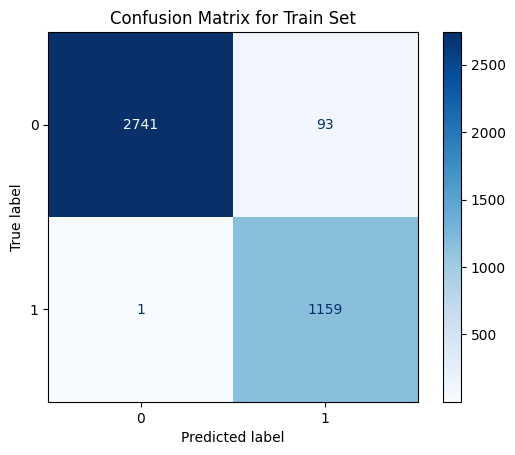

In [ ]:
# Confusion matrix display for Train set
confusionmatrix(X_train_vect, y_train, model = log_reg_model, set = "Train")

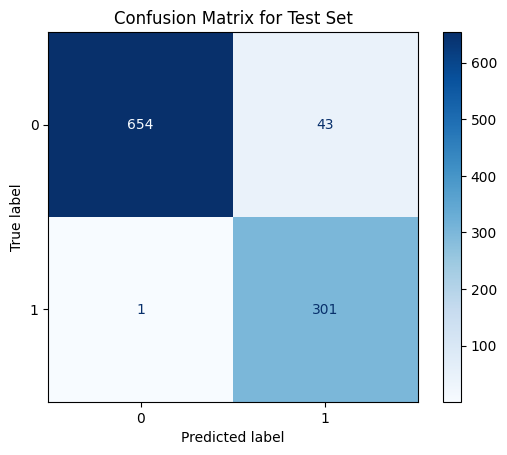

In [ ]:
# Confusion matrix display for Test set
confusionmatrix(X_test_vect, y_test, model = log_reg_model, set = "Test")

For both sets, the number of false negative is very low: only one email has been classified as ham while it is spam. </br>
On the other hand, the number of false positive is rather high, and it should be decreased because it appears more problematic to have a regular email classified as spam (false positive) than a spam classified ham (false negative). </br>
To change this tendency, the threshold value is changed, and its optimum value is investigated.

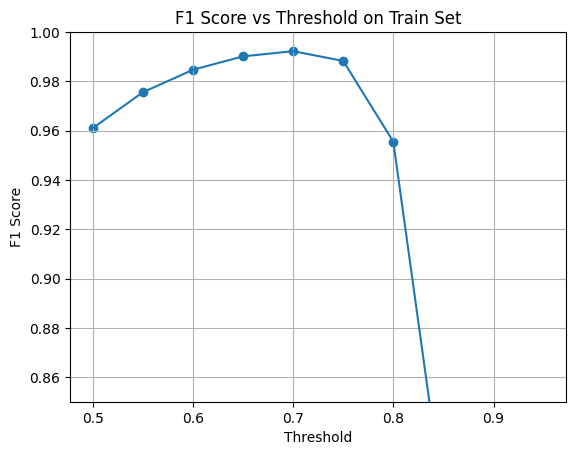

In [ ]:
# For threshold between 0.5 and 1, calculation of F1 score for train set
y_proba_train = log_reg_model.predict_proba(X_train_vect)[:, 1]
f1_list =[]
thresholds_list = []
for i in np.arange(0.5, 1.0, 0.05):
  y_pred_train = np.where(y_proba_train>i, 1, 0)
  f1 = f1_score(y_train, y_pred_train)
  f1_list.append(f1)
  thresholds_list.append(i)

# Plot of F1 score vs threshold values for train set (zoom on the higher F1 values)
plt.plot(thresholds_list, f1_list)
plt.scatter(thresholds_list, f1_list)
plt.ylim(0.85, 1)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold on Train Set")
plt.grid(True)
plt.show()

A threshold of 0.7 seems to give the best F1 score.

In [ ]:
# For a threshold = 0.7, performances on both sets
# Train set
y_pred_train = np.where(y_proba_train>0.7, 1, 0)
f1_train = f1_score(y_train, y_pred_train)

# Test set
y_proba_test = log_reg_model.predict_proba(X_test_vect)[:, 1]
y_pred_test = np.where(y_proba_test>0.7, 1, 0)
f1_test = f1_score(y_test, y_pred_test)
print(f"With a threshold of 0.7, performances on both sets are: \n"
      f"Train set: F1 score = {round(f1_train,3)}\n"
      f"Test set: F1 score = {round(f1_test,3)} ")

With a threshold of 0.7, performances on both sets are: 
Train set: F1 score = 0.992
Test set: F1 score = 0.967 


Confusion matrix of both sets are displayed with the new threshold value.

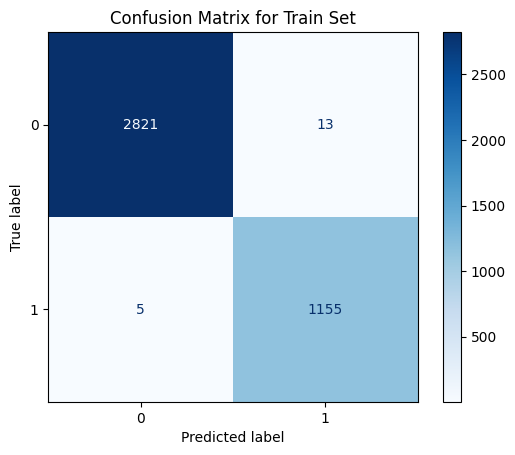

In [ ]:
confusionmatrix(X_train_vect, y_train, model = log_reg_model, set = "Train", y_pred = y_pred_train)

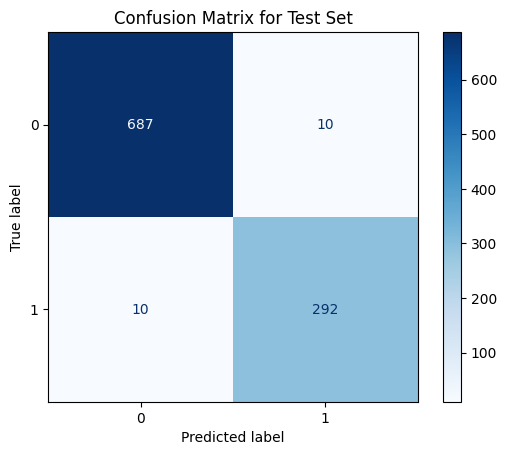

In [ ]:
confusionmatrix(X_test_vect, y_test, model = log_reg_model, set = "Test", y_pred = y_pred_test)

Considering the excellent results obtained with the logistic regression model, it is judged as satisfying.

# Main Topics in the SPAM emails

To identify the main topics in a text corpus, the Latent Dirichlet Allocation (LDA) model is widely used. To operate with it, it is necessary to go back to the original dataset, and to change the preprocessing pipeline: in fact a Bag Of Words vectorization (with counts and no weights as in TF-IDF) is required. </br>
The entire "spam" dataset is used, with no train-test split as it is not useful anymore.

In [ ]:
# The observations corresponding to SPAM emails have already been grouped in the dataframe called text_spam
print(f"Number of SPAM emails studied: {len(text_spam)}")

Number of SPAM emails studied: 1462


In [ ]:
# Function for data cleaning
def data_cleaning_lda(items):
  for item in items:
    yield(simple_preprocess(item, deacc = True))

In [ ]:
# Application of the function on the SPAM emails
datawords = list(data_cleaning_lda(text_spam))

The simple_preprocess function doesn't perform lemmatization, and it is useful to do it.

In [ ]:
# Function to perform lemmatization
def lemma(items):
  for item in items:
    # Join the list of words into a single string for spaCy processing
    doc = nlp(" ".join(item))
    # Extract lemmas and yield them as a list of words
    lemmatized_words = [token.lemma_ for token in doc]
    yield lemmatized_words

In [ ]:
# Application of the function
datawords = lemma(datawords)

In [ ]:
# Function to remove the stop words and words shorter than 5 characters
def remove_stopwords(texts):
  return[[word for word in words if word not in english_stopwords and len(word)>5]for words in texts]

In [ ]:
# Application of the function on the already cleaned dataset
datawords = remove_stopwords(datawords)

Now the dataset is fully cleaned, before vectorization of the documents it is necessary to create the vocabulary.

In [ ]:
# Vocabulary creation: give a number ID to each word present in the corpus
id2word = corpora.Dictionary(datawords)

In [ ]:
# Vectorization through BoW technique: each document (email) becomes a sparse vector
corpus = [id2word.doc2bow(text) for text in datawords]

In order to accurately choose the best number of topics, the coherence value of the topics found is calculated for different number of topics. The one with the highest coherence value is kept.

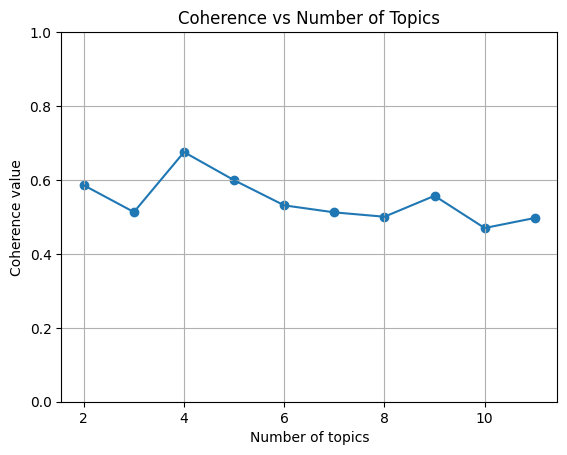

In [ ]:
# For loop on different number of topics to calculate the coherence
num_top =[]
coher = []
for i in np.arange(2, 12, 1):
  lda_model = LdaModel(corpus = corpus, id2word = id2word, num_topics = i, passes = 25, random_state =2)
  coherence_model = CoherenceModel(model=lda_model, texts=datawords, dictionary=id2word, coherence='c_v')
  coherence = coherence_model.get_coherence()
  num_top.append(i)
  coher.append(coherence)

# Plot of coherence value vs number of topics
plt.plot(num_top, coher)
plt.scatter(num_top, coher)
plt.ylim(0,1)
plt.xlabel("Number of topics")
plt.ylabel("Coherence value")
plt.title("Coherence vs Number of Topics")
plt.grid(True)
plt.show()

It seems that the best coherence value is obtained with 4 topics, and the coherence is beyond 0.6.

In [ ]:
# Creation of the LDA model with optimum number of topics
best_num_topics = 4
lda_model = LdaModel(corpus = corpus, id2word = id2word, num_topics = best_num_topics, passes = 25)

# Print of the topics
pprint(lda_model.print_topics())

[(0,
  '0.018*"company" + 0.010*"statement" + 0.008*"information" + 0.007*"height" '
  '+ 0.007*"security" + 0.006*"investment" + 0.006*"within" + 0.006*"report" + '
  '0.005*"business" + 0.005*"service"'),
 (1,
  '0.007*"viagra" + 0.007*"software" + 0.006*"online" + 0.006*"prescription" + '
  '0.006*"cialis" + 0.005*"professional" + 0.005*"microsoft" + 0.005*"office" '
  '+ 0.004*"window" + 0.004*"windows"'),
 (2,
  '0.002*"dosage" + 0.001*"online" + 0.001*"without" + 0.001*"female" + '
  '0.001*"benefit" + 0.001*"compendia" + 0.001*"saloonkeep" + '
  '0.001*"godparent" + 0.001*"metabole" + 0.001*"dreyfuss"'),
 (3,
  '0.011*"computron" + 0.009*"remove" + 0.008*"message" + 0.008*"contact" + '
  '0.008*"please" + 0.004*"special" + 0.004*"subject" + 0.004*"information" + '
  '0.004*"product" + 0.004*"dealer"')]


To semplify the visualization, for each topic a list of the most important words created.

In [ ]:
# For each topic, list with words and their relative probabilities
topics = lda_model.show_topics(num_topics=-1, num_words=10, formatted=False)

# Only the words are kept
topic_words = []

for topic_id, word_probs in topics:
    word_list = [w for w, p in word_probs]
    topic_words.append(word_list)
    print(f"Words for topic {topic_id}: {topic_words[topic_id]}")

Words for topic 0: ['company', 'statement', 'information', 'height', 'security', 'investment', 'within', 'report', 'business', 'service']
Words for topic 1: ['viagra', 'software', 'online', 'prescription', 'cialis', 'professional', 'microsoft', 'office', 'window', 'windows']
Words for topic 2: ['dosage', 'online', 'without', 'female', 'benefit', 'compendia', 'saloonkeep', 'godparent', 'metabole', 'dreyfuss']
Words for topic 3: ['computron', 'remove', 'message', 'contact', 'please', 'special', 'subject', 'information', 'product', 'dealer']


# Semantic Distance between the Topics

Embeddings technique is used to transform words in vectors in a semantic space. The pretrained 'glove-wiki-gigaword-300' model is chosen.

In [ ]:
# Instance of a pretrained model
glove_vector = gensim.downloader.load('glove-wiki-gigaword-300')

For each topic, topic_words list contains the 10 most frequent words. </br>
A vector representing them is created, and then the cosine similarity between each is calculated, in order to appreciate how distant or close are the vectors corresponding to the 7 topics.

In [ ]:
# Function to transform each list of words into a unique embedding vector
def avg_vector(sentence):
    to_remove = 0
    vector = np.zeros(300)
    for word in sentence:
        if word in glove_vector.key_to_index.keys():
            vector += glove_vector.get_vector(word)
        else:
            to_remove += 1
    if len(sentence)== to_remove:
        return np.zeros(300)

    return vector/(len(sentence)-to_remove)

In [ ]:
# Application of the function
topic_vectors = []
for i in range(0, len(topic_words)):
  vector = avg_vector(topic_words[i])
  topic_vectors.append(vector)

Now each of the 4 topics is represented by a unique vector, the cosine similarity can be calculated for each pair of topics.

In [ ]:
similarity_list = []
for i in range(0, len(topic_vectors)):
  similarity = []
  for j in range (0, len(topic_vectors)):
    sim = 1 - spatial.distance.cosine(topic_vectors[i], topic_vectors[j])
    similarity.append(round(sim,2))
  similarity_list.append(similarity)

In [ ]:
topic_list = []
for i in range (0, len(topic_vectors)):
  topic_list.append(f"Topic {i}")
df_similarity = pd.DataFrame(similarity_list, columns = topic_list, index = topic_list)
print(df_similarity)

         Topic 0  Topic 1  Topic 2  Topic 3
Topic 0     1.00     0.53     0.32     0.66
Topic 1     0.53     1.00     0.48     0.50
Topic 2     0.32     0.48     1.00     0.39
Topic 3     0.66     0.50     0.39     1.00


A deeper "manual" analysis is performed here to check the coherence of the data. </br>
Topic 0 words are : company, statement, information, height, security, within, investment, report, service and business so relative to **Business & Finance** topic. </br>
Topic 1 words are : viagra, software, prescription, online, cialis, professional, microsoft, office, window and health so here it seems that there 2 different topics mixed: **Health & Pharmaceutical** on one hand and **Software & Technology** on the other hand. </br>
Topic 2 words are : dosage, online, without, paliourg, benefit, dreyfuss, cognitive, compendia, proletariat and emotional so relative to **Health & Research** topic. </br>
Topic 3 words are : computron, remove, contact, message, please, special, subject, product, information and dealer so relative to **Business Correspondance** topic. </br> </br>

The topics 0 and 3 seem to be similar: in fact the similarity values is the highest in the entire dataset with 0.66. </br>
On the opposite, the topic 2 about health 7 research seems to be different compared to others, and in fact there is not similarity score higher than 0.45 with the other topics. </br> </br>
As a conclusion about the topics heterogeneity, one can say that there are clear different subjects in the SPAM emails.


# Information about Organizations in the regular emails

The aim of the last part of this project is it study the regular emails and identify the organizations named in them. It corresponds to a Named Entity Recognition (NER) task.</br>
To improve at the maximum the quality of the 'organizations' found, the model is changed for the 'en_core_web_trf' one which use a transformer and should be more accurate than 'en_core_web_sm' to recognize 'ORG' labelled words.

In [ ]:
nlp2 = spacy.load('en_core_web_trf')

In [ ]:
def entities(corpus):
  organizations = {}
  for sentence in corpus:
    doc = nlp2(sentence)
    for token in doc.ents:
      if str(token.label_) == "ORG":
        if str(token.text) in organizations:
          organizations[token.text]+=1
        else:
          organizations[token.text]=1
  return organizations

In [ ]:
# Application of the function to the regular emails
dict_org = entities(text_regular)

print(f"Number of identified organizations: {len(dict_org)}")

Number of identified organizations: 3369


Considering the very high number of organization names, some postprocessing can be done to pull out a clear list of the most frequent organizations named in the emails.

In [ ]:
# First, the organizations are listed from the most frequent one to the least frequent
sorted_dict_org = dict(sorted(dict_org.items(), key=lambda item: item[1], reverse=True))

# Then the organizations named less than 5 times are removed
filtered_dict = {k: v for k, v in sorted_dict_org.items() if v > 5}

# Finally, words of less than 3 letters are discarded as they often refer to internal codes
final_dict = {k: v for k, v in filtered_dict.items() if len(k) > 3}

# Print of final organizations names with thei frequency in the entire regular emails
print(final_dict)
print(f"The number of organizations once applied the different filters is {len(final_dict)}.")

{'enron': 1649, 'sitara': 371, 'enronxgate': 176, 'hplc': 173, 'unify': 170, 'texas utilities': 164, 'eastrans': 161, 'enron . com': 158, 'equistar': 137, 'teco': 111, 'tenaska iv': 106, 'enron north america corp': 99, 'entex': 94, 'duke': 76, 'wellhead': 72, 'enrononline': 64, 'midcon': 62, 'dynegy': 61, 'deal': 60, 'exxon': 59, 'pg & e': 54, 'fuels cotton valley': 54, 'pops': 53, 'tufco': 48, 'goliad co': 48, 'coastal oil & gas corporation': 46, 'devon': 43, 'enron _ development': 43, 'd & h gas company': 43, 'cdnow': 43, 'panenergy': 42, 'coastal': 39, 'enserch': 37, 'enron capital & trade resources corp': 37, 'hesco': 36, 'enron corp': 35, 'aepin': 35, 'iferc': 34, 'tenaska': 34, 'mobil': 34, 'valero': 33, 'apache': 33, 'calpine': 32, 'expedia . com': 32, 'expedia': 31, 'cilco': 30, 'enron corp .': 29, 'north america corp': 29, 'spinnaker': 27, 'epgt': 26, 'el paso': 26, 'mobil beaumont': 26, 'netco': 26, 'vance': 24, 'txu fuels': 24, 'ferc': 24, 'mops': 23, 'd & h': 23, 'beaumont 

It is visible that all the words identified as organizations with the ORG tag are not all correct. It is due to different reasons: organizations names are particularly variable (in opposition for example to person names, or localizations), they are often similar to other kinds of entites (Apple for example can be considered as the fruit, not as the company), in emails some organizations could be mentionned in an unformal way different than the one expected. </br>
As a conclusion here it is worthy to note that the most frequent organization name is 'enron', which is the company name from which a famous email dataset have been raised public. Thus we can hypothesize that this is part of this dataset, containing real emails from Enron employees. </br> </br>
The initial part of this work about classification method gave good results using a simple logistic regression model ; the second and third parts about analysis of the spam emails identified the diversity in the topics, and finally the part of analysis of the organizations named in the regular emails mainly showed that NER task may be very challenging.